# Uncertainty Propagation through Nonlinear Functions

When a Gaussian random variable $x \sim \mathcal{N}(\mu, \Sigma)$ passes
through a nonlinear function $f$, the output $y = f(x)$ is generally
**not** Gaussian. Different methods approximate the output distribution
$p(y)$ with varying fidelity.

## Motivation: uncertain inputs in Gaussian processes

The problem of propagating uncertainty through nonlinear maps arises
naturally in **Gaussian process (GP) models with uncertain inputs**.
At test time the input $x_*$ may itself be uncertain — for example:

- In **multi-step-ahead prediction** with GP dynamics models
  (Girard et al., 2003; Deisenroth & Rasmussen, 2011), the predicted
  state at time $t$ becomes the uncertain input at time $t{+}1$.
- In **GP-based policy search** (PILCO; Deisenroth & Rasmussen, 2011),
  the controller must evaluate a GP whose input is a belief state.
- In **heteroscedastic and input-noise models** (McHutchon & Rasmussen,
  2011), observation noise in the inputs induces effective output noise
  that depends on the local gradient of the GP posterior mean.

Given a GP posterior $f \mid \mathcal{D}$ and an input distribution
$x_* \sim \mathcal{N}(\mu_*, \Sigma_*)$, we seek the **predictive
moments**

$$\mathbb{E}[f(x_*)] = \int f(x)\,\mathcal{N}(x \mid \mu_*, \Sigma_*)\,dx,$$

$$\operatorname{Var}[f(x_*)] = \int \bigl(f(x)
  - \mathbb{E}[f(x_*)]\bigr)^2
  \,\mathcal{N}(x \mid \mu_*, \Sigma_*)\,dx.$$

For the squared-exponential kernel these integrals have analytic forms
(Quinonero-Candela et al., 2003), but for general kernels or composed
models they are intractable — and the methods compared below become
essential.

## Methods compared

This notebook compares five approaches available in gaussx:

| Method | Points | Key idea |
|--------|--------|----------|
| **Taylor 1st** | 1 (mean only) | Linearize $f$ at the mean |
| **Taylor 2nd** | 1 + Hessian | Add curvature correction |
| **Unscented** | $2N+1$ sigma points | Deterministic quadrature |
| **Monte Carlo** | $S$ random samples | Empirical moments |
| **Pure MC** | $S$ random samples | Direct histogram (ground truth) |

We propagate a 1-D Gaussian through a deliberately wiggly function
to expose how each method handles nonlinearity.

In [1]:
from __future__ import annotations

import warnings


warnings.filterwarnings("ignore", message=r".*IProgress.*")

import jax
import jax.numpy as jnp
import jax.random as jr
import lineax as lx
import matplotlib.pyplot as plt

import gaussx


jax.config.update("jax_enable_x64", True)

## The nonlinear function

We pick a function with an inflection point, asymmetry, and saturation
-- features that challenge linearisation-based methods:

$$f(x) = \sin(1.5\,x) \cdot \exp(-0.15\,x^2) + 0.3\,x$$

In [2]:
def f_nonlinear(x):
    """Wiggly nonlinear scalar function."""
    return jnp.sin(1.5 * x) * jnp.exp(-0.15 * x**2) + 0.3 * x


# Vectorised for plotting
f_vec = jax.vmap(f_nonlinear)

x_grid = jnp.linspace(-5, 5, 500)
y_grid = f_vec(x_grid)

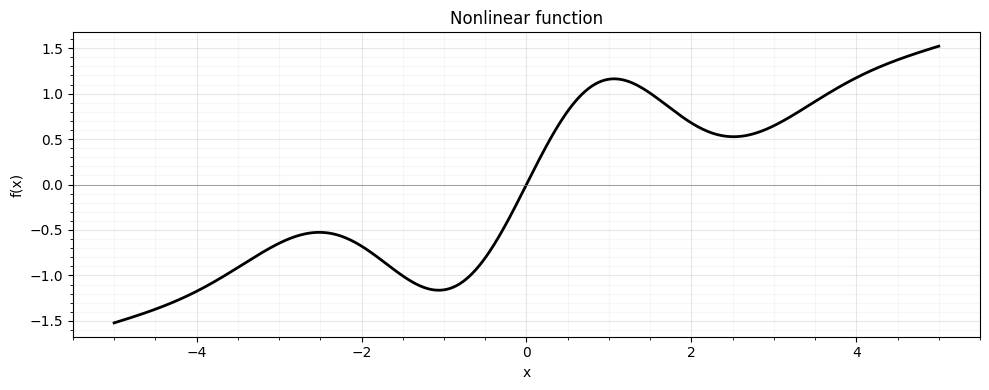

In [3]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(x_grid, y_grid, "k-", lw=2)
ax.set_xlabel("x")
ax.set_ylabel("f(x)")
ax.set_title("Nonlinear function")
ax.axhline(0, c="grey", lw=0.5)
ax.grid(True, which="major", alpha=0.3)
ax.grid(True, which="minor", alpha=0.1)
ax.minorticks_on()
plt.tight_layout()
plt.show()

## Input distribution

A 1-D Gaussian centred right where the function has strong curvature:

$$x \sim \mathcal{N}(\mu=1.0,\; \sigma^2=0.6)$$

In [4]:
mu_x = 1.0
sigma2_x = 0.6

state = gaussx.GaussianState(
    mean=jnp.array([mu_x]),
    cov=lx.MatrixLinearOperator(jnp.array([[sigma2_x]]), lx.positive_semidefinite_tag),
)

## Mathematical background

All methods below approximate the first two moments of $y = f(x)$
when $x \sim \mathcal{N}(\mu, \Sigma)$.

### Taylor 1st order (linearisation / EKF)

Expand $f$ to first order around the mean:

$$f(x) \approx f(\mu) + J\,(x - \mu), \qquad
  J = \left.\frac{\partial f}{\partial x}\right|_{x=\mu}.$$

Under this linear approximation the output is exactly Gaussian:

$$\mu_y = f(\mu), \qquad \Sigma_y = J\,\Sigma\,J^\top.$$

This is the update used in the **extended Kalman filter (EKF)**
(Anderson & Moore, 1979). It is exact when $f$ is affine, but ignores
curvature — the mean estimate is biased whenever $f''(\mu) \neq 0$.

### Taylor 2nd order

Including the second-order term of the Taylor expansion gives a
correction to the mean via the Hessian $H_i = \nabla^2 f_i(\mu)$:

$$\mu_{y,i} = f_i(\mu) + \tfrac{1}{2}\operatorname{tr}(H_i\,\Sigma).$$

The covariance remains the first-order expression $\Sigma_y = J\Sigma J^\top$
(computing the exact second-order covariance requires fourth moments of the
Gaussian, which is rarely worth the cost). This "second-order EKF" appears
in, e.g., Athans et al. (1968).

### Unscented transform (UT)

Instead of differentiating $f$, the UT (Julier & Uhlmann, 1997)
evaluates it at a minimal set of **sigma points**
$\{\mathcal{X}_i\}_{i=0}^{2N}$ chosen to match the mean and
covariance of $x$ exactly:

$$\mathcal{X}_0 = \mu, \qquad
  \mathcal{X}_i = \mu + \bigl(\sqrt{(N+\lambda)\,\Sigma}\bigr)_i, \qquad
  \mathcal{X}_{N+i} = \mu - \bigl(\sqrt{(N+\lambda)\,\Sigma}\bigr)_i,$$

where $\lambda = \alpha^2(N + \kappa) - N$ and $(\sqrt{M})_i$ denotes
the $i$-th column of the matrix square root. The output moments are
weighted sums:

$$\mu_y = \sum_i w_i^{(m)}\,f(\mathcal{X}_i), \qquad
  \Sigma_y = \sum_i w_i^{(c)}\bigl(f(\mathcal{X}_i) - \mu_y\bigr)
            \bigl(f(\mathcal{X}_i) - \mu_y\bigr)^\top.$$

The UT captures nonlinear effects up to third order for Gaussian inputs
(Julier & Uhlmann, 2004) and requires **no derivatives** of $f$.
It underpins the **unscented Kalman filter (UKF)** (Wan & van der Merwe,
2000).

### Monte Carlo moment matching

Draw $S$ samples $x^{(s)} \sim \mathcal{N}(\mu, \Sigma)$, push them
through $f$, and compute empirical moments:

$$\mu_y \approx \frac{1}{S}\sum_{s=1}^S f(x^{(s)}), \qquad
  \Sigma_y \approx \frac{1}{S}\sum_{s=1}^S
  \bigl(f(x^{(s)}) - \mu_y\bigr)\bigl(f(x^{(s)}) - \mu_y\bigr)^\top.$$

This is unbiased and converges at rate $O(1/\sqrt{S})$ regardless of
dimension — making it the method of choice when $N$ is large or $f$ is
very nonlinear. The moment-matched Gaussian is the best Gaussian
approximation in the KL sense and is used for "assumed density
filtering" in GP dynamics models (Deisenroth & Rasmussen, 2011).

## Run all five methods

In [5]:
# --- Taylor 1st order (EKF) ---
taylor1 = gaussx.TaylorIntegrator(order=1)
res_t1 = taylor1.integrate(lambda x: jnp.atleast_1d(f_nonlinear(x[0])), state)

# --- Taylor 2nd order ---
taylor2 = gaussx.TaylorIntegrator(order=2)
res_t2 = taylor2.integrate(lambda x: jnp.atleast_1d(f_nonlinear(x[0])), state)

# --- Unscented transform ---
ut = gaussx.UnscentedIntegrator(alpha=1.0, beta=2.0, kappa=0.0)
res_ut = ut.integrate(lambda x: jnp.atleast_1d(f_nonlinear(x[0])), state)

# --- Monte Carlo integrator (moment matching) ---
mc = gaussx.MonteCarloIntegrator(n_samples=50_000, key=jr.key(42))
res_mc = mc.integrate(lambda x: jnp.atleast_1d(f_nonlinear(x[0])), state)

# --- Pure MC: raw histogram as ground truth ---
key = jr.key(123)
n_pure = 200_000
x_samples = mu_x + jnp.sqrt(sigma2_x) * jr.normal(key, (n_pure,))
y_samples = f_vec(x_samples)
pure_mc_mean = jnp.mean(y_samples)
pure_mc_var = jnp.var(y_samples)

In [6]:
def _moments(res):
    m = float(res.state.mean[0])
    v = float(res.state.cov.as_matrix()[0, 0])
    return m, v


methods = {
    "Taylor 1st": _moments(res_t1),
    "Taylor 2nd": _moments(res_t2),
    "Unscented": _moments(res_ut),
    "MC (50k)": _moments(res_mc),
    "Pure MC (200k)": (float(pure_mc_mean), float(pure_mc_var)),
}

print(f"{'Method':<18s} {'Mean':>8s} {'Std':>8s}")
print("-" * 36)
for name, (m, v) in methods.items():
    print(f"{name:<18s} {m:8.4f} {jnp.sqrt(v):8.4f}")

Method                 Mean      Std
------------------------------------
Taylor 1st           1.1586   0.1036
Taylor 2nd           0.5085   0.9251
Unscented            0.6085   0.8062
MC (50k)             0.7388   0.5023
Pure MC (200k)       0.7358   0.5074


## Visualisation

The main plot shows:

- **Bottom x-axis**: the input Gaussian $p(x)$ as a filled curve.
- **Left y-axis**: the nonlinear function $f(x)$ (black curve).
- **Right side**: the output Gaussian approximations from each method,
  and the true output histogram from pure MC.

This makes it easy to see how the input bell curve "warps" through $f$
and how each approximation captures (or misses) the resulting skew.

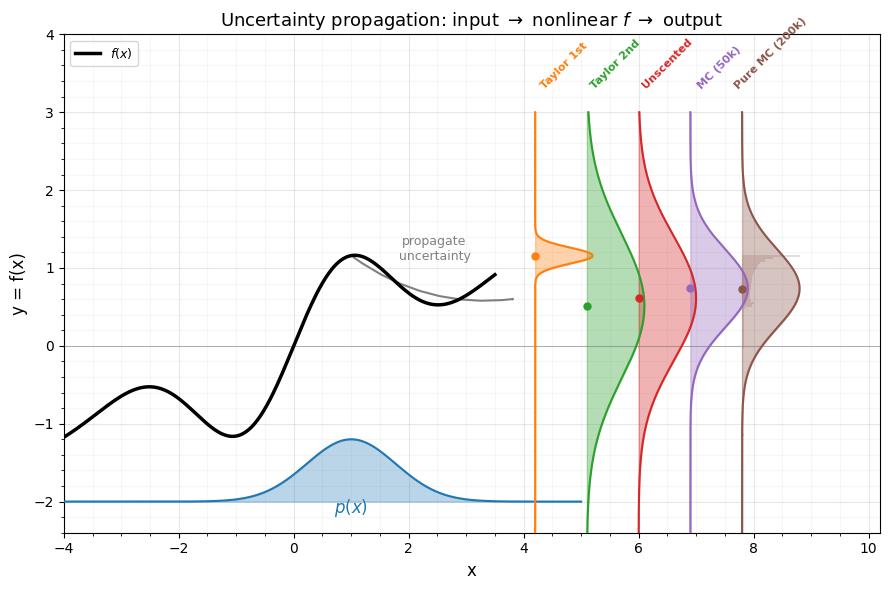

In [7]:
from matplotlib.patches import FancyArrowPatch
from scipy.stats import norm


fig, ax = plt.subplots(figsize=(9, 6))

# --- Nonlinear function (clip to x < x_right so it doesn't bleed) ---
x_fn = jnp.linspace(-4, 3.5, 400)
y_fn = f_vec(x_fn)
ax.plot(x_fn, y_fn, "k-", lw=2.5, label="$f(x)$", zorder=5)

# --- Input Gaussian (along x-axis) ---
x_pdf = norm.pdf(x_grid, loc=mu_x, scale=jnp.sqrt(sigma2_x))
# Scale so the peak is visually ~0.8 units tall on the y-axis
x_pdf_scaled = x_pdf / x_pdf.max() * 0.8
y_base = -2.0  # shift below the function
ax.fill_between(
    x_grid,
    y_base,
    y_base + x_pdf_scaled,
    color="C0",
    alpha=0.3,
    zorder=2,
)
ax.plot(x_grid, y_base + x_pdf_scaled, "C0-", lw=1.5, zorder=3)
ax.text(
    mu_x,
    y_base - 0.15,
    r"$p(x)$",
    ha="center",
    fontsize=12,
    color="C0",
)

# --- Output distributions (horizontal Gaussians) ---
colours = ["C1", "C2", "C3", "C4", "C5"]
x_right = 4.2
width = 1.0

y_range = jnp.linspace(-2.5, 3.0, 400)

for i, (name, (m, v)) in enumerate(methods.items()):
    s = jnp.sqrt(v)
    pdf_vals = norm.pdf(y_range, loc=m, scale=s)
    pdf_scaled = pdf_vals / pdf_vals.max() * width
    x_pos = x_right + i * 0.9

    ax.fill_betweenx(
        y_range,
        x_pos,
        x_pos + pdf_scaled,
        color=colours[i],
        alpha=0.35,
        zorder=2,
    )
    ax.plot(
        x_pos + pdf_scaled,
        y_range,
        color=colours[i],
        lw=1.5,
        zorder=3,
    )
    ax.plot(x_pos, m, "o", color=colours[i], ms=5, zorder=6)
    ax.text(
        x_pos + width * 0.5,
        3.3,
        name,
        ha="center",
        fontsize=8,
        color=colours[i],
        rotation=45,
        fontweight="bold",
    )

# --- Pure MC histogram (faint, behind the Gaussians) ---
hist_x_pos = x_right + 4 * 0.9
counts, bin_edges = jnp.histogram(y_samples, bins=80, density=True)
bin_centres = 0.5 * (bin_edges[:-1] + bin_edges[1:])
hist_scaled = counts / counts.max() * width
ax.barh(
    bin_centres,
    hist_scaled,
    left=hist_x_pos,
    height=bin_edges[1] - bin_edges[0],
    color="C5",
    alpha=0.2,
    zorder=1,
)

# --- Arrow showing the "propagation" ---
arrow = FancyArrowPatch(
    (mu_x, f_nonlinear(jnp.array(mu_x))),
    (x_right - 0.3, float(res_ut.state.mean[0])),
    arrowstyle="-|>",
    color="grey",
    lw=1.5,
    connectionstyle="arc3,rad=0.2",
    zorder=4,
)
ax.add_patch(arrow)
ax.text(
    (mu_x + x_right - 0.3) / 2,
    float(res_ut.state.mean[0]) + 0.5,
    "propagate\nuncertainty",
    ha="center",
    fontsize=9,
    color="grey",
)

# --- Formatting ---
ax.set_xlim(-4, x_right + 5 * 0.9 + 1.5)
ax.set_ylim(y_base - 0.4, 4.0)
ax.set_xlabel("x", fontsize=12)
ax.set_ylabel("y = f(x)", fontsize=12)
ax.set_title(
    r"Uncertainty propagation: input $\to$ nonlinear $f$ $\to$ output",
    fontsize=13,
)
ax.axhline(0, c="grey", lw=0.4)
ax.legend(loc="upper left", fontsize=9)
ax.grid(True, which="major", alpha=0.3)
ax.grid(True, which="minor", alpha=0.1)
ax.minorticks_on()
plt.tight_layout()
plt.show()

## Observations

1. **Taylor 1st order** uses only the local slope at $\mu$ -- it produces a
   symmetric Gaussian whose width depends on $|f'(\mu)|$. When $f$ curves
   strongly, this misses the mean shift.

2. **Taylor 2nd order** adds a Hessian correction to the mean
   ($\mu_y \mathrel{+}= \tfrac{1}{2}\operatorname{tr}(H \Sigma)$) and gets
   closer to the true mean, but the covariance is still first-order.

3. **Unscented transform** evaluates $f$ at $2N{+}1=3$ deterministic sigma
   points and captures the nonlinearity much better -- even with just 3
   function evaluations.

4. **Monte Carlo** (moment matching) converges to the true moments with
   enough samples. With 50k samples, the mean and variance match the pure
   MC histogram closely.

5. The **pure MC histogram** reveals that the true output distribution is
   slightly skewed -- something no Gaussian approximation can capture.
   All four methods project onto the best-fit Gaussian, which is the
   optimal thing to do for downstream linear-Gaussian inference (Kalman
   updates, variational inference, etc.).

## Error comparison

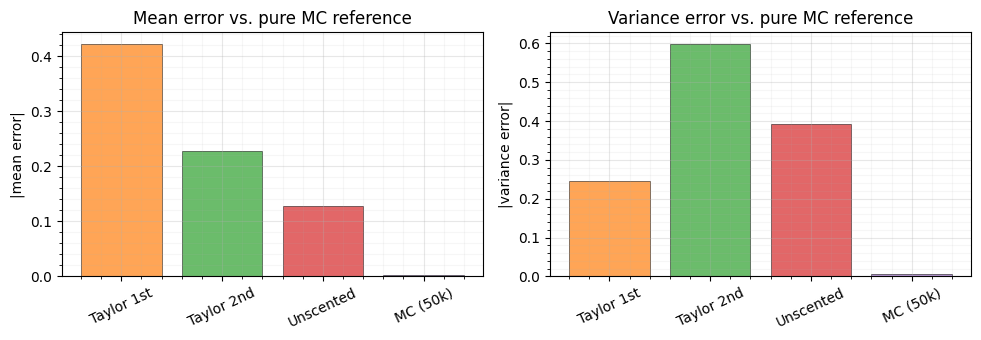

In [8]:
ref_mean, ref_var = float(pure_mc_mean), float(pure_mc_var)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

names = list(methods.keys())[:-1]
mean_errors = [abs(methods[n][0] - ref_mean) for n in names]
var_errors = [abs(methods[n][1] - ref_var) for n in names]
colours_bar = colours[:4]

axes[0].bar(
    names,
    mean_errors,
    color=colours_bar,
    alpha=0.7,
    edgecolor="k",
    lw=0.5,
)
axes[0].set_ylabel("|mean error|")
axes[0].set_title("Mean error vs. pure MC reference")
axes[0].tick_params(axis="x", rotation=25)
axes[0].grid(True, which="major", alpha=0.3)
axes[0].grid(True, which="minor", alpha=0.1)
axes[0].minorticks_on()

axes[1].bar(
    names,
    var_errors,
    color=colours_bar,
    alpha=0.7,
    edgecolor="k",
    lw=0.5,
)
axes[1].set_ylabel("|variance error|")
axes[1].set_title("Variance error vs. pure MC reference")
axes[1].tick_params(axis="x", rotation=25)
axes[1].grid(True, which="major", alpha=0.3)
axes[1].grid(True, which="minor", alpha=0.1)
axes[1].minorticks_on()

plt.tight_layout()
plt.show()

## When to use each method

| Method | Cost | Best for |
|--------|------|----------|
| Taylor 1st | $O(N^2)$ Jacobian | Mildly nonlinear, real-time EKF |
| Taylor 2nd | $O(N^3)$ Hessian | Moderate nonlinearity, small $N$ |
| Unscented | $O(N)$ function evals | Good default; no derivatives needed |
| Monte Carlo | $O(S)$ function evals | Complex functions, large $N$, reference |

All four methods are available in gaussx via the `AbstractIntegrator`
interface, so you can swap them with a single line change:

```python
integrator = gaussx.TaylorIntegrator(order=1)    # or
integrator = gaussx.UnscentedIntegrator()         # or
integrator = gaussx.MonteCarloIntegrator(n_samples=10000, key=jr.key(0))

result = integrator.integrate(f, state)
```

## Connection to GP prediction with uncertain inputs

In a trained GP with posterior mean $m(x)$ and variance $v(x)$, the
total predictive variance under input uncertainty decomposes as
(Girard et al., 2003, Eq. 2.40):

$$\operatorname{Var}[y_*] \;=\;
  \underbrace{\mathbb{E}_{x_*}[v(x_*)]}_{\text{noise / model variance}}
  \;+\;
  \underbrace{\operatorname{Var}_{x_*}[m(x_*)]}_{\text{input uncertainty}}.$$

The first term averages the GP's own uncertainty over plausible inputs;
the second is exactly the output variance computed by the methods
above, applied to the posterior mean function $m$.

For the **squared-exponential (RBF) kernel**, both expectations can be
evaluated in closed form because the required Gaussian-times-kernel
integrals are themselves Gaussian (Quinonero-Candela et al., 2003;
Deisenroth, 2010, Appendix A). For other kernels (Matern, periodic,
neural-network, etc.) or for compositions of GPs (deep GPs), the
integrals are intractable and the numerical methods in this notebook
are the standard approach.

The **PILCO** algorithm (Deisenroth & Rasmussen, 2011) chains these
moment-matching steps across a planning horizon $T$ to perform
gradient-based policy search in continuous state spaces, using the
analytic RBF moments where possible and falling back to the unscented
transform for the policy mapping.

## References

- Anderson, B. D. O. & Moore, J. B. (1979). *Optimal Filtering*.
  Prentice-Hall.
- Athans, M., Wishner, R. P., & Bertolini, A. (1968). Suboptimal state
  estimation for continuous-time nonlinear systems from discrete noisy
  measurements. *IEEE Trans. Automatic Control*, 13(5), 504--514.
- Deisenroth, M. P. (2010). *Efficient Reinforcement Learning using
  Gaussian Processes*. PhD thesis, Karlsruhe Institute of Technology.
- Deisenroth, M. P. & Rasmussen, C. E. (2011). PILCO: A model-based
  and data-efficient approach to policy search. *Proc. ICML*, 465--472.
- Girard, A., Rasmussen, C. E., Quinonero-Candela, J., & Murray-Smith,
  R. (2003). Gaussian process priors with uncertain inputs — application
  to multiple-step ahead time series forecasting. *Proc. NeurIPS 15*.
- Julier, S. J. & Uhlmann, J. K. (1997). A new extension of the Kalman
  filter to nonlinear systems. *Proc. AeroSense*, 182--193.
- Julier, S. J. & Uhlmann, J. K. (2004). Unscented filtering and
  nonlinear estimation. *Proc. IEEE*, 92(3), 401--422.
- McHutchon, A. & Rasmussen, C. E. (2011). Gaussian process training
  with input noise. *Proc. NeurIPS 24*.
- Quinonero-Candela, J., Girard, A., Larsen, J., & Rasmussen, C. E.
  (2003). Propagation of uncertainty in Bayesian kernel models —
  application to multiple-step ahead forecasting. *Proc. ICASSP*.
- Wan, E. A. & van der Merwe, R. (2000). The unscented Kalman filter
  for nonlinear estimation. *Proc. IEEE Adaptive Systems for Signal
  Processing, Communications, and Control Symposium*, 153--158.